<a href="https://colab.research.google.com/github/JulioRan09/Porgramacion-Predictiva/blob/main/Sesion12_Evaluacion_Analisis_Descriptivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre: Julio Rangel García**
- **Matrícula: 276572**

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [2]:
# 1.1 — Calcula la media, mediana y moda de la columna 'price'.

media = df['price'].mean()
mediana = df['price'].median()
moda = df['price'].mode()

print(f'Media: {media}')
print(f'Mediana: {mediana}')
print(f'Moda: {moda}')

Media: 152.7206871868289
Mediana: 106.0
Moda: 0    100
Name: price, dtype: int64


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Divergen, esto se debe a que hay valores atípicos, como vimos en clase, la media es un valor muy sensible a datos atípicos._

---
## Actividad 2 — Dispersión (20 pts)

In [3]:
# 2.1 — Calcula el rango, la varianza, la desviación estándar y el IQR (Q1, Q3, IQR) de 'price'.
rango = df['price'].max() - df['price'].min()
varianza = df['price'].var()
desviacion_estandar = df['price'].std()

q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1

print(f'Q1 es: {q1}, y Q3 es: {q3}')
print(f'El rango de la columna "price" es: {rango}')
print(f'La varianza de la columna "price" es: {varianza}')
print(f'La desviación estándar de la columna "price" es: {desviacion_estandar}')
print(f'El rango intercuartil de la columna "price" es: {iqr}')


Q1 es: 69.0, y Q3 es: 175.0
El rango de la columna "price" es: 10000
La varianza de la columna "price" es: 57674.02524696084
La desviación estándar de la columna "price" es: 240.15416974718727
El rango intercuartil de la columna "price" es: 106.0


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_El rango intercuartil es una medida más representativa de los datos, representa la distribución del 50% de los datos. Para este caso podemos ir más allá, si contamos que el valor mínimo es 0, y el Q3 es 175, podemos decir que el 75% de los datos están distribuidos entre 0 y 175, por lo que el rango de 10,000 está cargado por datos atípicos._

---
## Actividad 3 — Forma (20 pts)

In [4]:
# 3.1 — Calcula la asimetría (skew) y la curtosis (kurt) de 'price'.

sk_asimetry = df['price'].skew()
kurtosis = df['price'].kurtosis()

print(f'La asimetría de la columna "price" es: {sk_asimetry}')
print(f'La curtosis de la columna "price" es: {kurtosis}')


La asimetría de la columna "price" es: 19.118938995046033
La curtosis de la columna "price" es: 585.6728788988286


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Para los datos de la columna Price, encontramos una asimetría positiva más alta que los del ejemplo visto en clase, es una asimetría positiva lo que indica que los valores que generan la asimetría o la cola larga, son precios más altos que la mayoría de datos._
_Para la Kurtosis, nos encontramos con una Kurtosis alta, lo que nos indica que los valores "Outliers" no son tan comunes, y podemos esperar un pico alargado y alto alrededor de la mediana._

---
## Actividad 4 — Visualización (30 pts)

En el primer ejercicio se tomó la decisión de utilizar 50 bins para tratar de visualizar de mejor manera la zona más conglomerada, la cuál se encuentra aproximadamente entre 0 y 2000. Utilizar más Bins nos permitirá mejor resolución, pero pierde poder por culpa de los outliers.

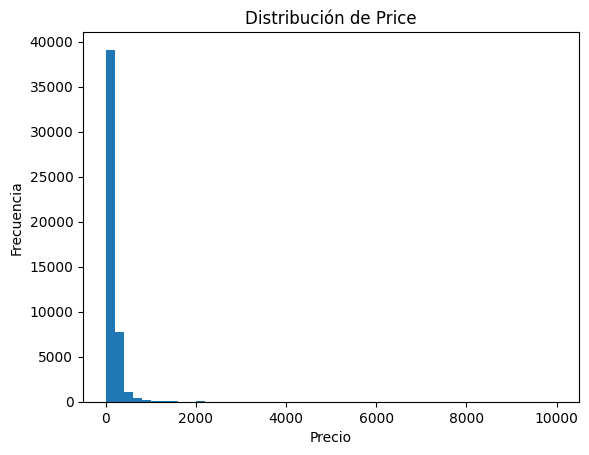

In [5]:
# 4.1 — Construye un histograma de 'price' con .plot(kind='hist').
# Elige un número de bins que te parezca razonable y comenta por qué lo elegiste.

df['price'].plot(kind='hist', bins=50, title='Distribución de Price')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()


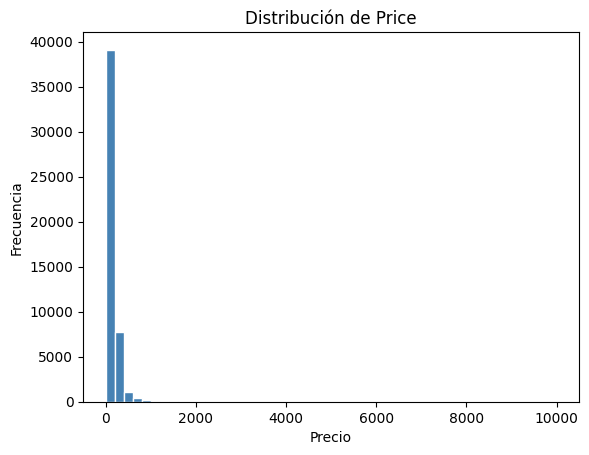

In [6]:
# 4.2 — Construye el mismo histograma con matplotlib.pyplot directamente (plt.hist()),
# agregando título y etiquetas en los ejes.

plt.hist(df['price'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribución de Price')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()


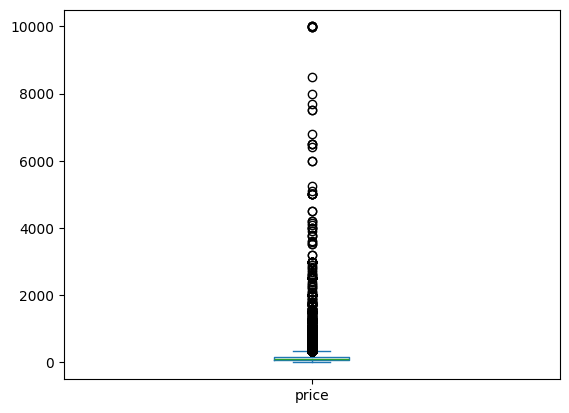

In [7]:
# 4.3 — Construye un boxplot de 'price' (con .plot(kind='box') o plt.boxplot()).
df['price'].plot(kind='box')
plt.show()


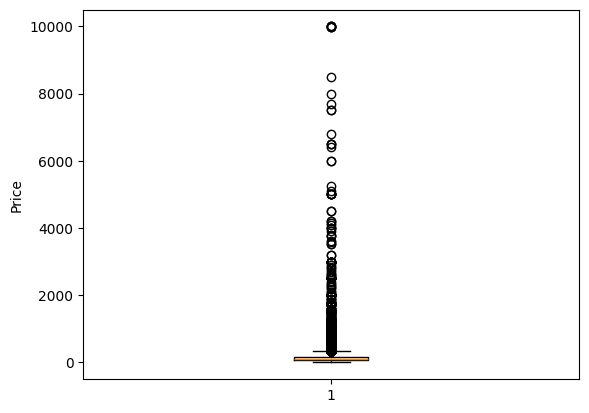

In [8]:
plt.boxplot(df['price'])
plt.ylabel('Price')
plt.show()


**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

_Tanto el histograma, como las gráficas boxplot nos muestran claramente el problema, los valores atípicos causan mucho ruido al momento de tratar de hacer un análisis gráfico. El histograma está claramente cargado alrededor de la mediana, como era de esperarse por el análisis de medias móviles. Mientras que el boxplot apenas logra apreciarse debido a los valores atípicos._
_No podemos decidir sólo basados en esto, si la mejor manera de tratar con ellos es desecharlos._

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de $152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

_Depende mucho del análisis que estemos buscando. Si bien la media puede ser engañosa y no representa bien la mayoría de los precios, sí nos indica algo importane, estos precios tienen un rango muy amplio._
_Para un análisis de los precios medios de una vivienda, casas de millones de dólares meterían ruido al resultado y podría no ser útil contar con estos datos. En este caso, la mediana representaría mejor los precios comunes de vivir en equis ciudad._

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |